# PCA

### Task 1: Exploratory Data Analysis (EDA):

In [1]:
## 1.	Load the dataset and perform basic data exploration.
## 2.	Examine the distribution of features using histograms, box plots, or density plots.
## 3.	Investigate correlations between features to understand relationships within the data.

In [2]:
## Import required libraries..
import pandas as pd
import numpy as np

In [3]:
## Load he dataset and display top 5 records..
df = pd.read_csv("wine.csv")
df.head(5)

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [5]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [6]:
df["Type"].value_counts()

Type
2    71
1    59
3    48
Name: count, dtype: int64

In [7]:
## The dataset consists of 178 records and 14 numericals columns related to wine characteristics..
## There are no missing values..dataset is clean and ready for analysis..
## The variable "Type" represents three categories of wine (1,2 and 3)..
## They ("Type" feature) are slightly imbalanced but all classes are reasonably represented..

In [8]:
## The dataset contains multiple chemical properties such as alcohol content, acidity, phenols and color intensity..
## Features like Alcohol, Ash, Phenols and Hue have relatively narrow ranges indicating less variability..
## Features such as Malic acid, Color, intensity and Proline show wide ranges, means higher variability in these characteristic..
## Proline and Magnesium have significantly larger scales compared to other features..

In [9]:
## The presence of different scales across features indicates the need for standardization before applying PCA or clustering algorithms..

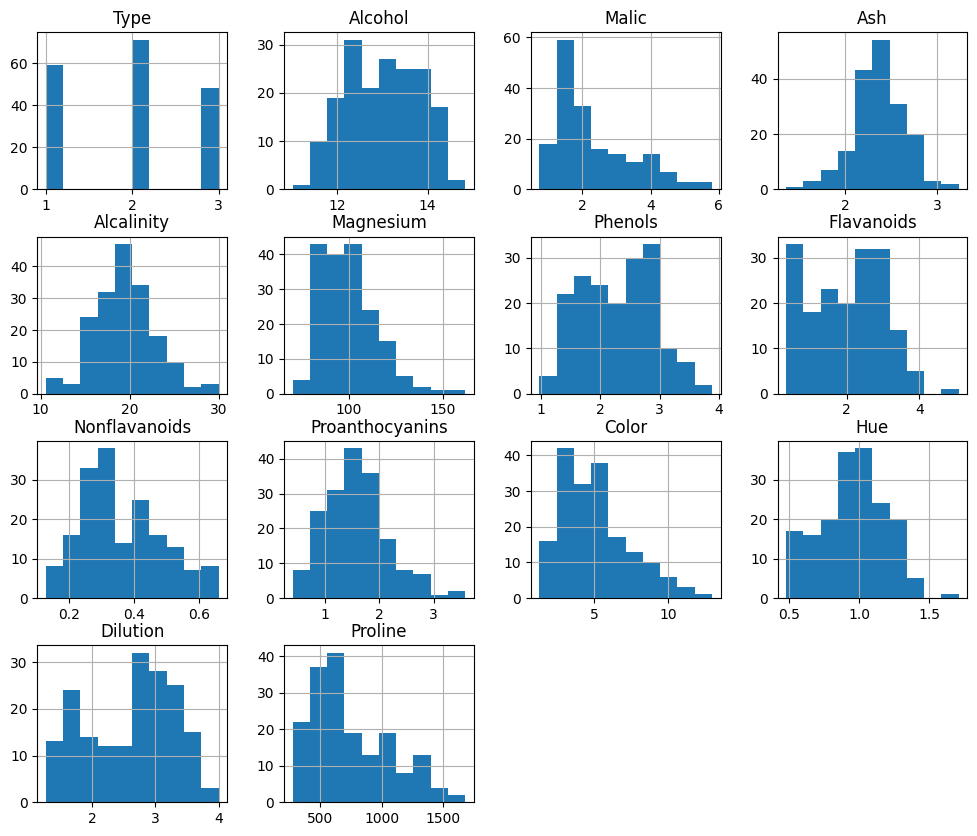

In [10]:
## Histogram plots.. 
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize = (12, 10))
plt.show()

In [11]:
## The Type variable shows three distinct categories  confirming the presence of three wine categories.. slightly imbalanced but moderate..
## Feature like Alcohol, Ash, Alcalinity, Hue and Proanthocyanins appears approximately normally distributed..indicates symmetric data with no strong skewness..

## Variable such as Malic acid, Color and Proline show right-skewed distrbutions.. 
## Majority of the observations are concentrated at the lower values with few higher value outliers..

## Magnesium and Flavanoids show moderate spread with slight skewness  indicating some variability across column..
## Features like Nonflavanoids and Dilution appear relatively compact suggesting less variation compared to other features..
## Some features exibits long tails especially Proline and Color indicating the presence of  noice or potential outliers..

## Overall the datset contain mix of normally distributed  and skewed  features .. 
## So standardization is required before applying PCA and clustering algorithms..

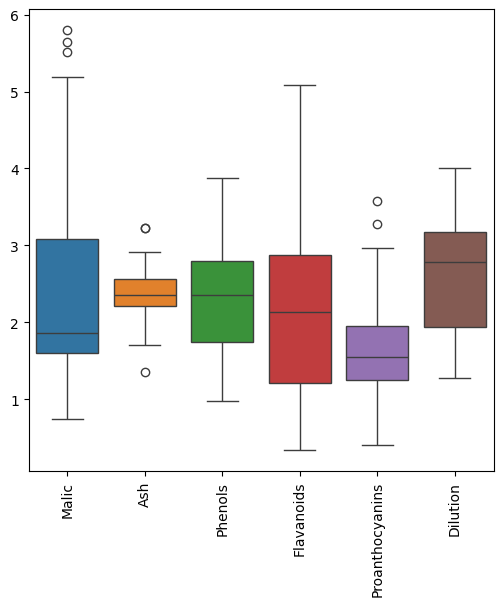

In [12]:
## Boxplots..
## I will be grouping features with similar scale together for better display of boxplots..
## If i fit all the features within single block of code then features with comparitively lower scale gets compressed..
## it will not be possible to interpret them..

plt.figure(figsize = (6, 6))
sns.boxplot(data = df[['Malic', 'Ash',  'Phenols', 'Flavanoids', 'Proanthocyanins', 'Dilution' ]])
plt.xticks(rotation = 90)
plt.show()

In [13]:
## For features like Malic (right skewed) and Dilution (left-skewed) clear skewness can be seen as the median is shifted more toward either of the side of the box.. 
## For feartures like Ash, Phenols, Flavanoids and Proanthocyanins, data is almost evenly distributed..a slight skewness can be observed thats all..

## Variables such as Maliac, Flavanoids and Dilution have taller boxes with longer whiskers indicating more variation (spread) in the data.. 
## Phenols and Proanthocyanins with moderate variations can be seen..
## Ash has comparitively compact box with shorter whiskers, which indicates values being more consistent and close to each other and tightly grouped in this column..

## Potential Outlier points can be seen in Malic, Ash and Proanthocyanins..
## they needs to be checked before removal because they could be important or unusual observation as well..

## Ash has comparitively more consistent data with little variation because its box and whiskers are small.. 
## Rest of the variables have moderate variation..

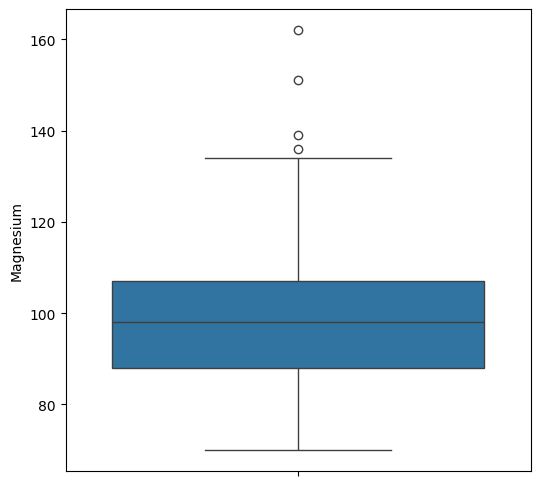

In [14]:
plt.figure(figsize = (6,6))
sns.boxplot(data = df["Magnesium"])
plt.xticks(rotation = 90)
plt.show()

In [15]:
## For Magnesium data is almost evenly distributed with median at centre to both upper and lower quartile..and similar whiskers lengths.. 
## The spread is on moderate side with few potential outliers at the upper whiskers end..
## Mild right skewness can be observed as median is almost at the centre but upper whisker being slightly taller..

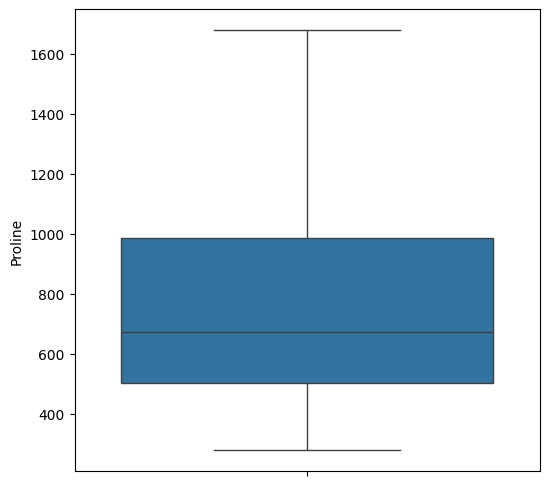

In [16]:
plt.figure(figsize = (6,6))
sns.boxplot(data = df['Proline'])
plt.xticks(rotation = 90)
plt.show()

In [17]:
## For Proline data is unevenly distributed with median being closer to lower quartile..
## and upper whisker is also significantly taller indicating right skew in the coloumn..
## It has huge spread (variation) in data (most in the dataset).. 
## No potential outliers can be seen.. 
## Longer upper whisker indicates more spread out data toward that end.. 
## the middle 50% of the data has moderate spread and tightly grouped along with lower whiskers side data in comparision with data around upper whisker..

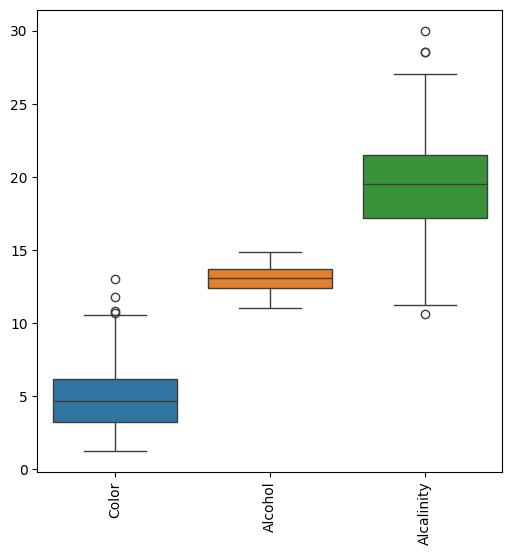

In [18]:
plt.figure(figsize = (6,6))
sns.boxplot(data = df[['Color', 'Alcohol', 'Alcalinity']])
plt.xticks(rotation = 90)
plt.show()

In [19]:
## All three of them have median almost at the centre indicating no skewness in the data.. 
## But Color has slight taller whisker with few potential outliers toward the same end indicating slight right skewness in the column..
## Aclalinity has almost similar whiskers length but few potential outliers can be seen..
## Most of the data is centered for Alcohol and Alcalinity..

## The spread of the data is moderate for Color and Alcalinity.. 
## The data in Alcohol is tightly grouped with consistent data with little variation..

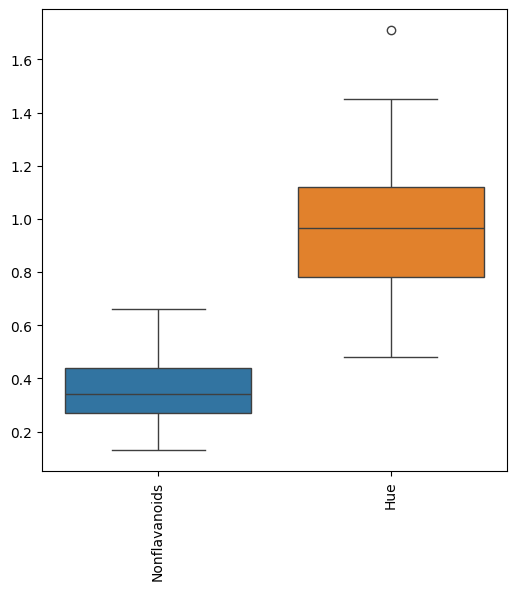

In [20]:
plt.figure(figsize = (6,6))
sns.boxplot(data = df[[ 'Nonflavanoids', 'Hue']])
plt.xticks(rotation = 90)
plt.show()

In [21]:
## Median of Nonflavanoids is slightly toward lower quartile(25%) and upper whisker being slightly taller at the same time indicates mild skewness.. spread is also very short..
## Median is almost at the centre for Hue, maybe mild allignment toward upper quartile but it negligible considering the spread..
## and Whikers are almost equal with short spread.. this means data is tightly grouped with consistent data with little variation..
## 1 potential outlier can be seen toward the upper whisker of Hue..

In [22]:
## Lets calculate and display few impotant statistical values related to Outliers detection just to see and have an idea about data distribution.
for i in df.columns:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    min_val = df[i].min()
    max_val = df[i].max()

    ## detect outliers..
    outliers = df[(df[i] < lower_bound) | (df[i] > upper_bound)][i]

    print(f"\nColumn: {i}")
    print(f"Q1 : {Q1}")
    print(f"Q3 : {Q3}")
    print(f"IQR : {IQR}")
    print(f"Lower Bound : {lower_bound}")
    print(f"Upper Bound : {upper_bound}")
    print(f"Minimum Value : {min_val}")
    print(f"Maximum Value : {max_val}")
    print(f"Potential Outiers : {len(outliers)}")
#    if len(outliers) > 0:
#        print("Potential Outliers:")
#        print(outliers.values)
    print("*"*100)


Column: Type
Q1 : 1.0
Q3 : 3.0
IQR : 2.0
Lower Bound : -2.0
Upper Bound : 6.0
Minimum Value : 1
Maximum Value : 3
Potential Outiers : 0
****************************************************************************************************

Column: Alcohol
Q1 : 12.362499999999999
Q3 : 13.6775
IQR : 1.3150000000000013
Lower Bound : 10.389999999999997
Upper Bound : 15.650000000000002
Minimum Value : 11.03
Maximum Value : 14.83
Potential Outiers : 0
****************************************************************************************************

Column: Malic
Q1 : 1.6025
Q3 : 3.0825
IQR : 1.48
Lower Bound : -0.6174999999999997
Upper Bound : 5.3025
Minimum Value : 0.74
Maximum Value : 5.8
Potential Outiers : 3
****************************************************************************************************

Column: Ash
Q1 : 2.21
Q3 : 2.5575
IQR : 0.34750000000000014
Lower Bound : 1.6887499999999998
Upper Bound : 3.0787500000000003
Minimum Value : 1.36
Maximum Value : 3.23
Potential Ou

In [23]:
## Above steps is a proof about the presence of potential outliers in some variables which are very less in counts.. 
## Although we will not be removing them in aggresive manner unless our model fails perform decently.. 

In [24]:
df.columns

Index(['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')

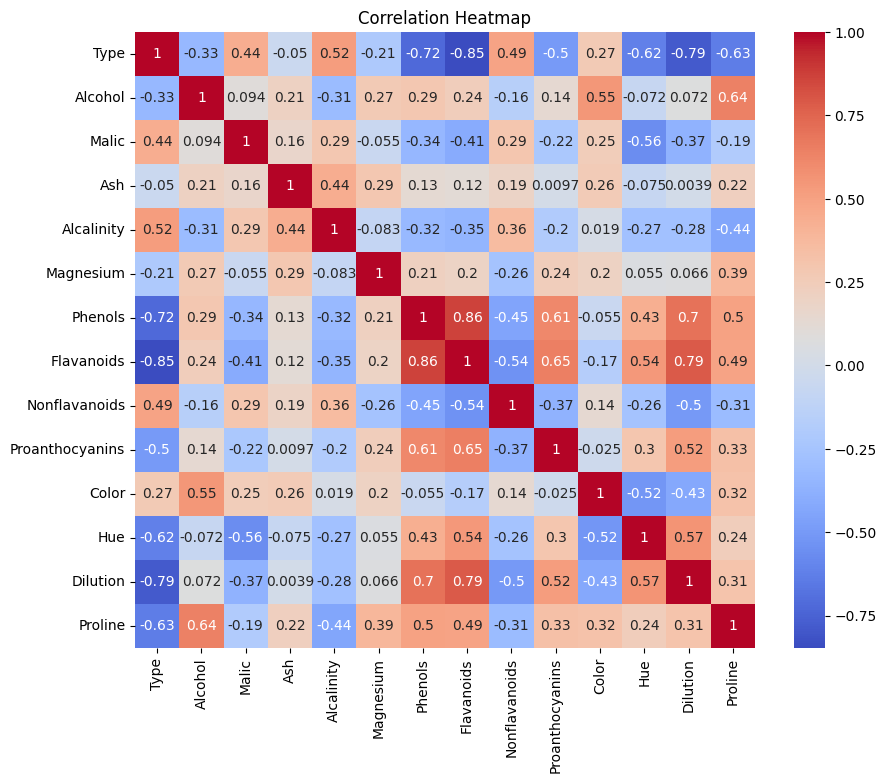

In [25]:
## Correlation Heatmap.. 
plt.figure(figsize = (10, 8))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [26]:
## There are strong positive correlations observed.. 
## Phenol~Flavanoids (0.86) very high.. Flavanoids~Dilution (0.79).. Phenol~Dilution (0.70)..
## There are some strong negative correlations as well..
## Flavanoids~NonFavanoids (-0.54).. Type~Favanoids (-0.85).. indicating inverse relationships between them..
## At the same time some features are moderately correlated as well..
## Alcohol~Proline (0.64).. Color~Alcohol (0.55)..
## Several features have weak or near zero correlation as well.. meaning they conribute independent information..
## Presence of high correlation = muticollinearity 
## Conclusion is the dataset shows significant multicollinearity among features making it a suitable dataset for PCA to reduce dimensionality while preserving maximum possible variance at the same time..

In [27]:
## we will not use VIF here to deal with multicollinearity, let PCA handel it..because its unsupervised learning..
## PCA will transform correlated variables into uncorrelated principle components..

### Task 2: Dimensionality Reduction with PCA:

In [28]:
## 1.	Standardize the features to ensure they have a mean of 0 and a standard deviation of 1. Implement PCA to reduce the dimensionality of the dataset.
## 2.	Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.
## 3.	Transform the original dataset into the principal components

In [29]:
## Standardize 
from sklearn.preprocessing import StandardScaler

In [30]:
## Lets drop "Type" before scalling because it actually a wine category label.. nominal.. 
## Even though it has numerical values like 1,2,3.. but difference between level and mathematical formulas will not make any sense on them.. 
## Also we dont want model to see it.. we want unbaised results.. 

In [31]:
X = df.drop("Type", axis = 1)

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
## The dataset contains features with varying scales..
## Standardization was applied to transform all features into same scale with mean = 0 and standard deviation = 1..
## This ensures that all variables contribute equally to the principle components..

In [34]:
## Apply PCA (Dimensionality Reduction)
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [35]:
## Explain variance..
explained_variance = pca.explained_variance_ratio_
print(explained_variance)

## PC4 explains about 7% of the variance.. after that each contribute very less, between (2-5%)

[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


In [36]:
cumulative_variance = np.cumsum(explained_variance)
print(cumulative_variance)

[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


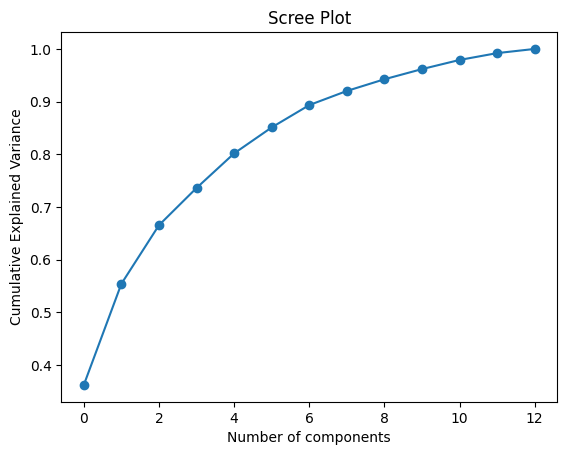

In [37]:
## Scree plot 
plt.plot(cumulative_variance, marker = "o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.show()

In [38]:
## This curve shows a sharp increase till 4th or 5th component only or maybe till 6th.. after that curve became flatter..
## This can be considered as the elbow point of this curve..
## Either we select 5 components (80% variance).. good balance between information plus dimensionality reduction.. 
## or we select 6-7 components (85-90% variance).. slightly more information retention..
## I will go with 5 principle components which is capturing around 80% of the total variance..its more practical to real world scenario..

In [39]:
## Original features = 13, i reduced it to 5.. so i basically reduced 60%  of the dimensions with minimum information loss.. 
## It can be considered as strong result..

In [40]:
## Lets transform the dataset using selected number of components..
pca = PCA(n_components = 5)
X_pca = pca.fit_transform(X_scaled)

### Task 3: Clustering with Original Data:

In [41]:
## 1.	Apply a clustering algorithm (e.g., K-means) to the original dataset.
## 2.	Visualize the clustering results using appropriate plots.
## 3.	Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.

In [42]:
## Apply K-Means.. 
## Since in the original dataset i already saw Type has 3 categories, we will use n_clusters = 3..
from sklearn.cluster import KMeans

kmeans= KMeans(n_clusters = 3, random_state = 42)
kmeans_labels_original = kmeans.fit_predict(X_scaled) 

C:\Users\devlok\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


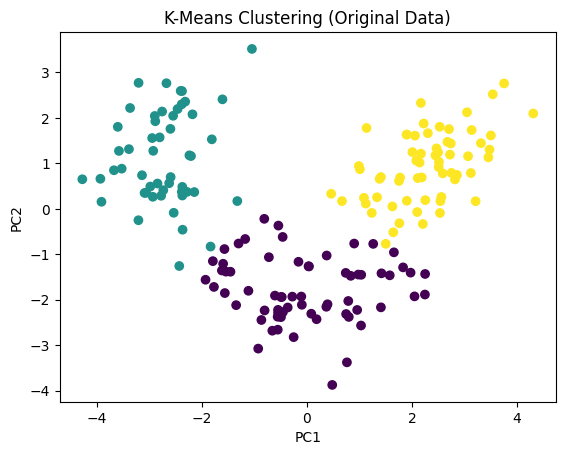

In [43]:
## Lets use PCA for visualisation purpose..because dataset has 13 dimensions.. 
## lets use first 2 priciple components just for visualization
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = kmeans_labels_original)
plt.title("K-Means Clustering (Original Data)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [44]:
## The scatter plot shows 3 clearly distinguishable clusters..
## Seperation is maily happining along PC1 axis.. Right side yellow cluster well seperated from others..
## Left side gree cluster another distinct group..
## Bottom cluster purple group, slighty closer still seperable..
## Overlapping between clusters is almost minimal therefore we can say that K-Means was able to capture structure reasonably well..

In [45]:
## Evaluation.. silhoutte score
from sklearn.metrics import silhouette_score

In [46]:
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels_original)
print("Silhouette Score:", kmeans_silhouette)

Silhouette Score: 0.2848589191898987


In [47]:
## Score is 0.2848.. this means moderate cluster quality, clusters are not perfect but acceptable..
## Some points maybe near boundaries..
## Some natural grouping can be seen but not extreamely strong..

In [48]:
## Cluster profiling..
df["KMeans_cluster_original"] = kmeans_labels_original
df.groupby("KMeans_cluster_original").mean()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
KMeans_cluster_original,,,,,,,,,,,,,,
0,2.000000,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231
1,2.941176,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
2,1.048387,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806


In [49]:
## Cluster 0: Balanced and medium profile wines.. Alcohol is bit lower, phenols and flavanoids are moderate, proline is on lower side.. moderate wines, not rich chemically..
## Cluster 1: Low phenolic, high color wines.. alcohol is moderate, flavanoids is low.. wines with low chemical richness but color intensity is high..
## Cluster 2: High quality.. Alcohol is maximum.. phenol is high, flavanoids very high, proline very high.. high quality wines, rich in chemical composition.. premium segment..

In [50]:
## overall insight: K-Means succesfully divided wines into 3 categories of low/ average quality wines, color dominant wines and high quality wines..
## Clusters are meaningful, interpretable and allignedwith real world wine characteristic..

### Task 4: Clustering with PCA Data:

In [51]:
## Apply K-Means on PCA data..
kmeans_pca = KMeans(n_clusters = 3, random_state = 42)
kmeans_labels_pca = kmeans_pca.fit_predict(X_pca)

C:\Users\devlok\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


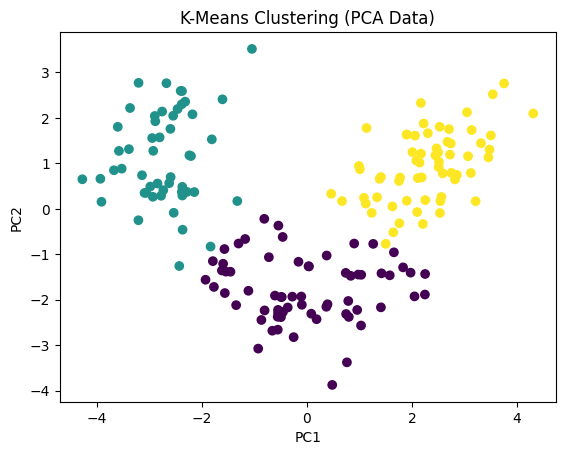

In [52]:
## Visualization..by using 1st 2 PCA components..
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = kmeans_labels_pca)
plt.title("K-Means Clustering (PCA Data)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [53]:
## The scatter plot shows 3 clearly distinguishable clusters..
## Seperation is maily happining along PC1 axis just like scatter plot for kmeans original lables..minimum overlap here also..
## PCA preserved the underlying cluster structure..
## No loss of important information despite dimentionality reduction.. 
## The plot look almost identical  to original clustering..

In [54]:
## Evaluation..
silhouette_score_pca = silhouette_score(X_pca, kmeans_labels_pca)
print("Silhouette Score (PCA):", silhouette_score_pca)

Silhouette Score (PCA): 0.3690763194699229


In [55]:
## score = 0.3690 (for pca data) , earlier it was 0.28.. improvement observed..
## Clusters are now more compact means point are within clusters..clusters can be considered as better seperated with each other..
## PCA improved the clustering by removing the noice and redundant features.. 

In [56]:
## Cluster profiling.. 
## it has to be done on real data set (orignal).. because PCA components are just mathematical combinations.. they have no real world meaning..
df["KMeans_cluster_pca"] = kmeans_labels_pca
df.groupby("KMeans_cluster_pca").mean()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,KMeans_cluster_original
KMeans_cluster_pca,,,,,,,,,,,,,,,
0,2.000000,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231,0.0
1,2.941176,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824,1.0
2,1.048387,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806,2.0


In [57]:
## Cluster 0: Moderate wines.. Alcohol is bit lower, phenols and flavanoids are moderate, proline is on lower side.. average quality wine and not rich chemically..
## Cluster 1: Low phenolic, high color wines.. alcohol is moderate, flavanoids is low.. wines with low chemical richness but color intensity is high..
## Cluster 2: High quality.. Alcohol is maximum.. phenol is high, flavanoids very high, proline very high.. high quality wines, rich in chemical composition.. premium segment..

In [58]:
## Even after PCA cluster remained same, cluster meaning remained same but quality improved (high silhouette score)..
## PCA reduced dimensionality without losing information..

## Scatter looks almost same.. this means PCA retained the important structure and no distrotion in data.. 

### Task 5: Comparison and Analysis:

In [59]:
## 1.	Compare the clustering results obtained from the original dataset and PCA-transformed data.
## 2.	Discuss any similarities or differences observed in the clustering results.
## 3.	Reflect on the impact of dimensionality reduction on clustering performance.
## 4.	Analyze the trade-offs between using PCA and clustering directly on the original dataset.

In [60]:
## Comparison
## Both original and PCA transformed data produced 3 clusters.. The cluster structure and grouping of data points remained almost same..
## Cluster profiling also showed very similar cxharateristics in both the cases..
## However the silhouette score improved from 0.28 (original data) --> 0.36 (PCA data)
## This indicates PCA produced better defined clusters..

In [61]:
## Similarities.. 
## Same number of clusters, similar cluster patterns in scatter plots, 
## cluster charateristic also remained same, no major change in grouping.. 

## Difference..
## Higher silhouette score for PCA data.. maybe slightly better seperation and compactness..
## Reduced featuire space from 13 --> 5

In [62]:
## Impact of PCA
## It reduced dimensionality while preserved most of the variance..
## It removed multicollinearity (redundant feature)..
## As a result cluster became more compact and better seperated.. 
## improved clustering performance without changing the underlying structure..

In [63]:
## Trade offs (PCA vs original data)

## Advantages of PCA
## Reduced dimensionality (faster computation), removed multicollinearity, improved cluster quality, reduced noice
## Disadvantages of PCA
## Loss of interpretability (as i said above pca components are not meaningful), difficut to explain results using it, additional preprocessing step..

## Advantages of original data
## Easy interpretation, Direct business insights..
## Disadvantages of original data
## Slightly lower clustering performace.. contain correlated features..

### Task 6: Conclusion and Insights

In [64]:
## 1.	Summarize the key findings and insights from the assignment.
## 2.	Discuss the practical implications of using PCA and clustering in data analysis.
## 3.	Provide recommendations for when to use each technique based on the analysis conducted.

In [65]:
## Key findings..
## K-Means clustering on the original data produced 3 meaningful clusters representing different types of wine..
## PCA reduced the dimensionality from 13 to 5 components while retaining most of the variance..
## Clustering on PCA transformed data resulted in similar cluster structure with improved silhouette score..
## Cluster profiling showed that one cluter represents high quality wine with richness in chemicals..
## one cluster represents moderate while one represents color dominant but chemically lighter wines..

In [66]:
## Practical implications
## K-Means clustering helps in grouping similar data points useful in product segmentation, customer grouping and pattern discovery..
## PCA helps in reducing dimesionality, removing redundant/correlated fetaures and improving model performance..
## Together PCA + KMeans helps in efficient and better clustering of high dimensional data.. 

In [67]:
## Recommendations..
## Use PCA when dataset has many features, there is multicollinearity, and you want to improver clustering performance..
## Use original data when interpretability is important and you need clear feature based insights..
## This assignment show that PCA enhances clustering performance by simplifying the dataset,
## While KMeans effectively identifies meaningful groups, macking their combinations highly useful for real world data analysis.. 